# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 50000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 50000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 50000)
y_test shape: (20000,)


## Random Forest Model Training

In [6]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
start_time = time.time()
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    warm_start=False
)
rf_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training Random Forest Classifier...
Training completed in 7.2282 seconds


## Model Evaluation

In [7]:
# Make predictions
y_pred = rf_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("RANDOM FOREST CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

RANDOM FOREST CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8141
Precision: 0.8490
Recall:    0.7624
F1-Score:  0.8034
Training Time: 7.2282 seconds


## Classification Report

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.76      0.80      9966
    Positive       0.79      0.87      0.82     10034

    accuracy                           0.81     20000
   macro avg       0.82      0.81      0.81     20000
weighted avg       0.82      0.81      0.81     20000



## Confusion Matrix Visualization

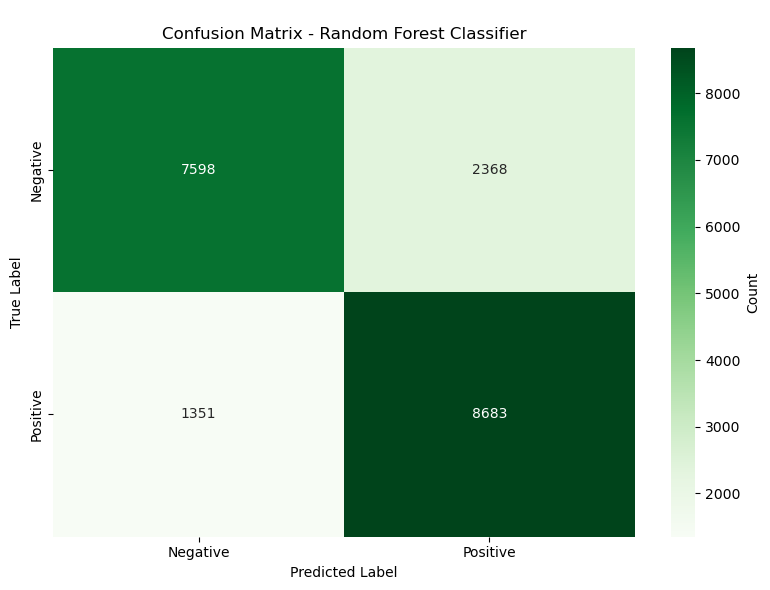

Confusion Matrix:
[[7598 2368]
 [1351 8683]]

True Negatives: 7598
False Positives: 2368
False Negatives: 1351
True Positives: 8683


In [9]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - Random Forest Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('random_forest_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Importance

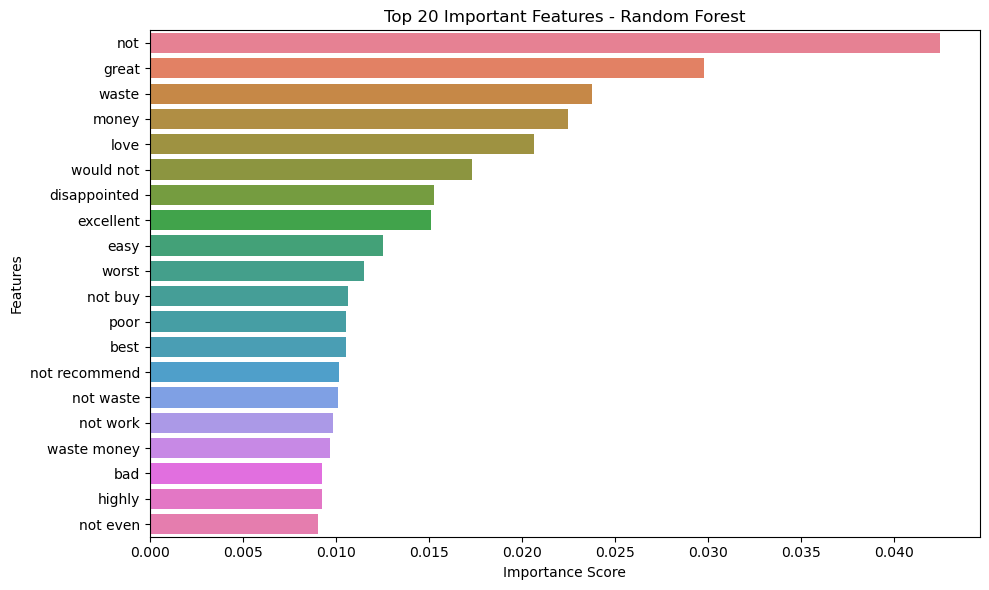


Top 20 Important Features:
      feature  importance
          not    0.042501
        great    0.029812
        waste    0.023774
        money    0.022496
         love    0.020635
    would not    0.017322
 disappointed    0.015279
    excellent    0.015115
         easy    0.012516
        worst    0.011513
      not buy    0.010665
         poor    0.010571
         best    0.010541
not recommend    0.010155
    not waste    0.010099
     not work    0.009846
  waste money    0.009700
          bad    0.009268
       highly    0.009243
     not even    0.009047


In [10]:
# Get feature importance
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = rf_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='husl')
plt.title('Top 20 Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Model Summary

In [11]:
print("RANDOM FOREST MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Number of Estimators: {rf_classifier.n_estimators}")
print(f"  - Max Depth: {rf_classifier.max_depth}")
print(f"  - Min Samples Split: {rf_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {rf_classifier.min_samples_leaf}")
print(f"  - Max Features: {rf_classifier.max_features}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")

RANDOM FOREST MODEL SUMMARY

Model Parameters:
  - Number of Estimators: 200
  - Max Depth: 20
  - Min Samples Split: 10
  - Min Samples Leaf: 5
  - Max Features: sqrt

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8141
  - Precision: 0.8490
  - Recall:    0.7624
  - F1-Score:  0.8034
  - Training Time: 7.2282 seconds


## Saving the Model and Pipeline

In [12]:
save(model_base='data/models', model=rf_classifier, model_name='10_random_forest_classifier.joblib')

Saved model 10_random_forest_classifier.joblib to data/models/10_random_forest_classifier.joblib


{'model': PosixPath('data/models/10_random_forest_classifier.joblib')}